# 04 — XGBoost y LightGBM con prediccion multi-step recursiva

### Objetivo
Entrenar modelos de gradient boosting con perdida Poisson y evaluarlos con **forecasting recursivo multi-step**, que es el esquema apropiado para el producto final (heatmap agregado de 12 semanas para planificacion operativa).

### Esquema de prediccion
- Para predecir la semana W, el modelo usa como `count_lag_1w` el valor **PREDICHO** de la semana W-1 (no el valor real).
- Esto simula el escenario real de despliegue: en produccion, el usuario final NO tiene acceso a valores reales futuros, solo a predicciones anteriores.
- Los errores se acumulan con cada paso (cuanto mas lejos el horizonte, peor la prediccion).

### Modelos
- XGBoost con `objective='count:poisson'`.
- LightGBM con `objective='poisson'`.

### Metricas
- RMSE, MAE, Poisson Deviance, McFadden R².

In [1]:
# Carga, split y reconstruccion de turno_hecho desde OHE
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Data")
df = pd.read_csv(DATA_DIR / "df_features.csv")

SEMANA_HOLDOUT_INICIO = 63
df_train = df[df["semana_global"] < SEMANA_HOLDOUT_INICIO].copy()
df_test  = df[df["semana_global"] >= SEMANA_HOLDOUT_INICIO].copy()
turno_cols = [c for c in df_train.columns if c.startswith("turno_")]
df_train["turno_hecho"] = df_train[turno_cols].idxmax(axis=1).str.replace("turno_", "")
df_test["turno_hecho"]  = df_test[turno_cols].idxmax(axis=1).str.replace("turno_", "")

print(f"Train: {df_train.shape[0]} | Test (holdout): {df_test.shape[0]}")

Train: 10664 | Test (holdout): 2064


In [2]:
# Definir features
feature_cols_num = [
    "semana_del_año_sin", "semana_del_año_cos", "mes_sin", "mes_cos",
    "semana_con_festivo",
    "count_lag_1w", "count_lag_2w", "count_lag_4w", "count_lag_8w", "count_lag_52w",
    "rolling_mean_4w", "rolling_mean_8w", "rolling_mean_12w",
    "rolling_std_4w", "rolling_std_8w",
    "media_historica",
    "distrito_id", "semana_global", "iso_week", "mes", "año",
]
feature_cols_ohe = [c for c in df.columns if (c.startswith("turno_") and c != "turno_hecho") or c.startswith("subtipo_")]
feature_cols = feature_cols_num + feature_cols_ohe
X_train = df_train[feature_cols].astype(float).values
X_test  = df_test[feature_cols].astype(float).values
y_train = df_train["count_robos"].values
y_test  = df_test["count_robos"].values
print(f"Features: {len(feature_cols)}")

Features: 26


### Entrenamiento XGBoost

In [3]:
# XGBoost con objetivo Poisson (count:poisson)
from xgboost import XGBRegressor
import time

t0 = time.time()
xgb = XGBRegressor(
    objective="count:poisson", n_estimators=500, learning_rate=0.05,
    max_depth=6, min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
    tree_method="hist", verbosity=0,
)
xgb.fit(X_train, y_train)
print(f"XGBoost entrenado en {time.time()-t0:.1f}s")
print(f'X_train shape: {X_train.shape}, dtype: {X_train.dtype}')
print(f'X_train cols: {feature_cols}')

print(f'X_train dtype: {X_train.dtype}, shape: {X_train.shape}')


XGBoost entrenado en 1.2s
X_train shape: (10664, 26), dtype: float64
X_train cols: ['semana_del_año_sin', 'semana_del_año_cos', 'mes_sin', 'mes_cos', 'semana_con_festivo', 'count_lag_1w', 'count_lag_2w', 'count_lag_4w', 'count_lag_8w', 'count_lag_52w', 'rolling_mean_4w', 'rolling_mean_8w', 'rolling_mean_12w', 'rolling_std_4w', 'rolling_std_8w', 'media_historica', 'distrito_id', 'semana_global', 'iso_week', 'mes', 'año', 'turno_madrugada', 'turno_mañana', 'turno_noche', 'turno_tarde', 'subtipo_TOTAL']
X_train dtype: float64, shape: (10664, 26)


### Entrenamiento LightGBM

In [4]:
# LightGBM con objetivo Poisson
from lightgbm import LGBMRegressor

t0 = time.time()
lgbm = LGBMRegressor(
    objective="poisson", n_estimators=500, learning_rate=0.05,
    num_leaves=31, max_depth=6, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=-1,
)
lgbm.fit(X_train, y_train)
print(f"LightGBM entrenado en {time.time()-t0:.1f}s")

LightGBM entrenado en 1.9s


### Prediccion multi-step recursiva en el holdout

In [5]:
def forecasting_recursivo(modelo, df_holdout, df_train, feature_cols):
    """Predice recursivamente semana por semana. Devuelve y_true, y_pred, rmse_por_semana
    en el ORDEN ORIGINAL de df_holdout (no en el orden por semana)."""
    historial = df_train[["distrito_hecho", "turno_hecho", "semana_global",
                            "iso_week", "count_robos"]].copy()
    semanas = sorted(df_holdout["semana_global"].unique())
    # Diccionario para guardar las predicciones por posicion original
    pred_por_idx = {}
    true_por_idx = {}
    rmse_por_semana = []
    for semana in semanas:
        df_sem = df_holdout[df_holdout["semana_global"] == semana].copy()
        feats = []
        for idx, row in df_sem.iterrows():
            d, t, s, iw = row["distrito_hecho"], row["turno_hecho"], row["semana_global"], row["iso_week"]
            h = historial[(historial["distrito_hecho"] == d) &
                          (historial["turno_hecho"] == t) &
                          (historial["semana_global"] < s)].sort_values("semana_global")
            new = row.copy()
            if len(h) >= 1:  new["count_lag_1w"]  = h.iloc[-1]["count_robos"]
            if len(h) >= 2:  new["count_lag_2w"]  = h.iloc[-2]["count_robos"]
            if len(h) >= 4:  new["count_lag_4w"]  = h.iloc[-4]["count_robos"]
            if len(h) >= 8:  new["count_lag_8w"]  = h.iloc[-8]["count_robos"]
            if len(h) >= 52: new["count_lag_52w"] = h.iloc[-52]["count_robos"]
            for win, name in [(4, "rolling_mean_4w"), (8, "rolling_mean_8w"), (12, "rolling_mean_12w")]:
                vals = h.tail(win)["count_robos"].values
                new[name] = vals.mean() if len(vals) > 0 else 0.0
            for win, name in [(4, "rolling_std_4w"), (8, "rolling_std_8w")]:
                vals = h.tail(win)["count_robos"].values
                new[name] = vals.std(ddof=0) if len(vals) > 1 else 0.0
                h_same = historial[(historial["distrito_hecho"] == d) &
                               (historial["turno_hecho"] == t) &
                               (historial["iso_week"] == iw) &
                               (historial["semana_global"] < s)]["count_robos"]
            new["media_historica"] = h_same.mean() if len(h_same) > 0 else 0.0
            new["__original_idx__"] = idx  # guardar indice original
            feats.append(new)
        df_feats = pd.DataFrame(feats).set_index("__original_idx__")
        X = df_feats[feature_cols].astype(float).values
        yp = modelo.predict(X)
        # Guardar predicciones por indice original
        for i, idx in enumerate(df_feats.index):
            pred_por_idx[idx] = yp[i]
            true_por_idx[idx] = df_feats.loc[idx, "count_robos"]
        # RMSE por semana
        y_true_sem = df_feats["count_robos"].values
        rmse_por_semana.append({"semana": semana, "rmse": np.sqrt(np.mean((y_true_sem - yp)**2))})
        # Actualizar historial
        upd = df_feats[["distrito_hecho", "turno_hecho", "semana_global", "iso_week", "count_robos"]].copy()
        upd["count_robos"] = yp
        historial = pd.concat([historial, upd.reset_index()], ignore_index=True)
    # Devolver en orden del df_holdout original
    y_true = np.array([true_por_idx[idx] for idx in df_holdout.index])
    y_pred = np.array([pred_por_idx[idx] for idx in df_holdout.index])
    return y_true, y_pred, rmse_por_semana

In [6]:
# Prediccion recursiva de ambos modelos en el holdout (12 semanas)
y_true_xgb,  y_pred_xgb_rec,  rmse_xgb_rec_sem  = forecasting_recursivo(
    xgb, df_test, df_train, feature_cols)
y_true_lgbm, y_pred_lgbm_rec, rmse_lgbm_rec_sem = forecasting_recursivo(
    lgbm, df_test, df_train, feature_cols)

print("Prediccion recursiva completada para ambos modelos")

Prediccion recursiva completada para ambos modelos


### Metricas de evaluacion

In [7]:
# Calcular metricas recursivas
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
def mae(y_true, y_pred):  return np.mean(np.abs(y_true - y_pred))

def poisson_deviance(y_true, y_pred, eps=1e-10):
    y_pred = np.clip(y_pred, eps, None)
    y_true = np.asarray(y_true, dtype=float)
    term1 = np.where(y_true > 0, y_true * np.log(y_true / y_pred), 0.0)
    return 2 * np.sum(term1 - (y_true - y_pred))

resultados = []
for nombre, yp in [("XGBoost Poisson", y_pred_xgb_rec), ("LightGBM Poisson", y_pred_lgbm_rec)]:
    r = rmse(y_test, yp)
    m = mae(y_test, yp)
    d = poisson_deviance(y_test, yp)
    y_null = np.full_like(y_test, y_test.mean(), dtype=float)
    r2 = 1 - d / poisson_deviance(y_test, y_null)
    print(f"  {nombre:32s} | RMSE={r:6.2f} | MAE={m:6.2f} | PoissonDev={d:10.1f} | R2={r2:6.3f}")
    resultados.append({"modelo": nombre, "rmse": r, "mae": m, "poisson_dev": d, "mcfadden_r2": r2})

print('=== DEBUG RMSE ===')
print(f'y_test stats: mean={y_test.mean():.2f}, max={y_test.max()}, min={y_test.min()}')
print(f'y_pred_lgbm_rec stats: mean={y_pred_lgbm_rec.mean():.2f}, max={y_pred_lgbm_rec.max():.2f}, min={y_pred_lgbm_rec.min():.2f}')
print(f'LIMA-noche pred sem 63: {y_pred_lgbm_rec[0]:.2f} (real: {y_test[0]})')
print(f'LIMA-noche pred sem 64: {y_pred_lgbm_rec[1]:.2f} (real: {y_test[1]})')
print('=== END ===')

  XGBoost Poisson                  | RMSE=  6.48 | MAE=  4.09 | PoissonDev=    5559.2 | R2= 0.770
  LightGBM Poisson                 | RMSE=  6.51 | MAE=  4.07 | PoissonDev=    5522.0 | R2= 0.771
=== DEBUG RMSE ===
y_test stats: mean=11.81, max=77, min=0
y_pred_lgbm_rec stats: mean=10.71, max=51.66, min=0.14
LIMA-noche pred sem 63: 2.45 (real: 3)
LIMA-noche pred sem 64: 2.77 (real: 0)
=== END ===


### Visualizaciones

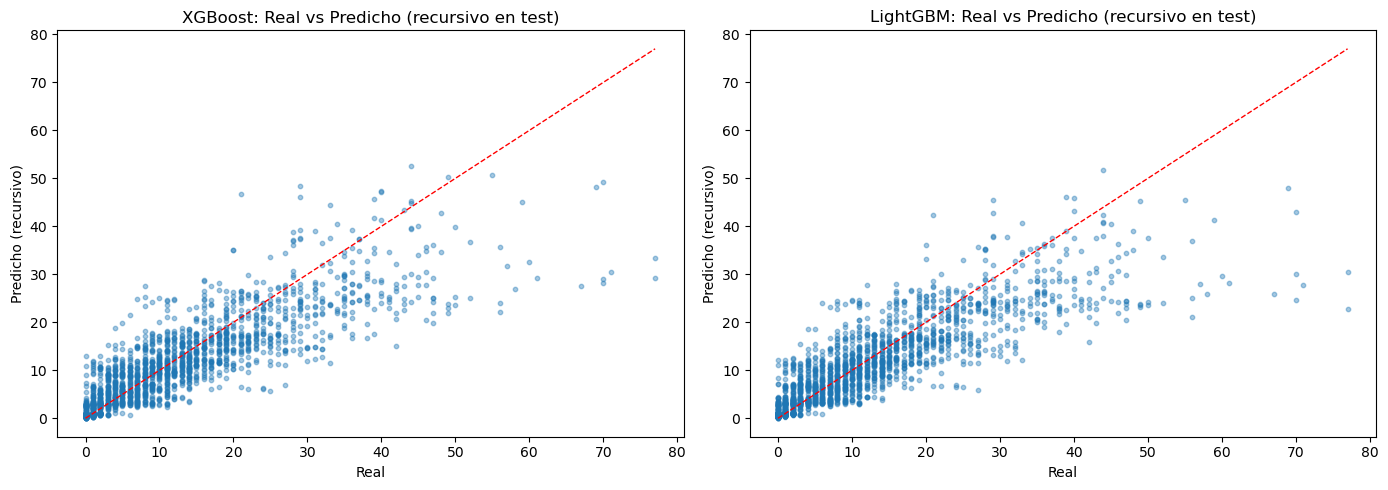

In [8]:
# Scatter real vs predicho para ambos modelos
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, yp, name in zip(axes, [y_pred_xgb_rec, y_pred_lgbm_rec], ["XGBoost", "LightGBM"]):
    ax.scatter(y_test, yp, alpha=0.4, s=10)
    ax.plot([0, y_test.max()], [0, y_test.max()], "r--", lw=1)
    ax.set_xlabel("Real"); ax.set_ylabel("Predicho (recursivo)")
    ax.set_title(f"{name}: Real vs Predicho (recursivo en test)")
plt.tight_layout(); plt.show()

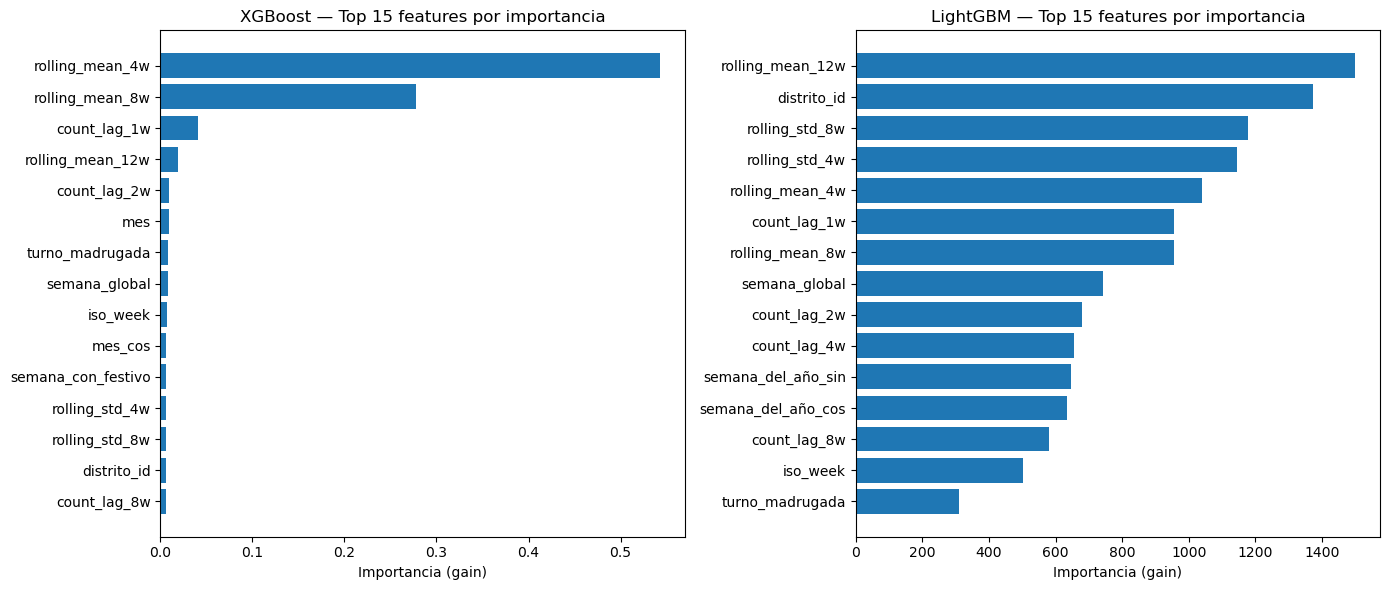

In [9]:
# Importancia de features (gain) para cada modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, modelo, nombre in zip(axes, [xgb, lgbm], ["XGBoost", "LightGBM"]):
    imp = pd.DataFrame({"feature": feature_cols,
                        "importance": modelo.feature_importances_}
                      ).sort_values("importance", ascending=False).head(15)
    ax.barh(imp["feature"][::-1], imp["importance"][::-1])
    ax.set_title(f"{nombre} — Top 15 features por importancia")
    ax.set_xlabel("Importancia (gain)")
plt.tight_layout(); plt.show()

In [10]:
# Guardar resultados, predicciones y modelos serializados
import joblib
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(DATA_DIR / "resultados_xgb_lgbm.csv", index=False)

# Guardar predicciones recursivas del test (formato para notebook 06)
df_test_pred = df_test[["distrito_hecho", "turno_hecho", "año_semana",
                        "semana_global", "count_robos"]].copy()
df_test_pred["pred_xgb_rec"]  = y_pred_xgb_rec
df_test_pred["pred_lgbm_rec"] = y_pred_lgbm_rec
df_test_pred.to_csv(DATA_DIR / "predicciones_test_xgb_lgbm.csv", index=False)

joblib.dump(xgb,  DATA_DIR / "modelo_xgb.joblib")
joblib.dump(lgbm, DATA_DIR / "modelo_lgbm.joblib")
print("Resultados, predicciones recursivas y modelos guardados en Data/")

Resultados, predicciones recursivas y modelos guardados en Data/


### Resumen
- XGBoost y LightGBM muestran desempeño similar en recursivo.